# Imports

In [69]:
###################################
#This package assumes you are working on HPC with a folder structure like:
# Project
#  -> scripts
#     -> pancan_pipe (this repository)
#        -> this_notebook.ipynb
#  -> data
#     -> possible_subfolder
#        -> he_wsi_images.svs / .ome.tiff / etc
#  -> sampleinfo
#     -> sample_list.tsv (Created below)
#  -> results
#     -> infer_outputs will go here
#  -> logs
#     -> info about your pipeline run will go here
###################################

In [14]:
import os
import sys
from subprocess import Popen, PIPE
from pathlib import Path
from tqdm import tqdm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

#Note, base must be an absolute path (not relative) for containers to use it correctly later e.g.:
prj = "HCC-CBS-209-Hillman-ASinghi-HE-Class-Final"
base = Path('/ix/rbao/Projects', prj)
scripts= base.joinpath('scripts')
results = base.joinpath('results','predict_full','v1')
results.mkdir(parents=True,exist_ok=True)
sampleinfo = base.joinpath('sampleinfo')
results.mkdir(parents=True,exist_ok=True)
logs = base.joinpath('logs','full_round1') #Edit this to manage different runs, round2, round3 etc.
logs.mkdir(parents=True,exist_ok=True)
data = base.joinpath('data','all_raw_nospace')
data.exists()

True

# 1) Create sample_list.tsv 

## a) Warning: files with spaces in the names will cause problems! Make .svs filenames without spaces or use renamed symlinks!

### Make directory of symlinks to .svs (manually or with code)

In [15]:
file_type = '.svs'
for i,im in enumerate(tqdm(data.glob('*%s' % file_type))):
    a = im.parts[-1]
    b = a.replace(' ','_')
    # print(b)
    os.rename(im.parent.joinpath(a),im.parent.joinpath(b))

578it [00:01, 310.82it/s]


## b) Inference: from a data directory with all files in one location 

In [28]:
file_type = '.svs'
samples = pd.DataFrame([])
for i,im in enumerate(data.glob('*%s' % file_type)):
    fn = im.parts[-1]
    samples.loc[i,'task'] = int(i+1)
    samples.loc[i,'slide'] = fn
    samples.loc[i,'slide_path'] = str(im)   
    # samples.loc[i,'anno_path'] = im.parts[-1].split('.')[0] + '.geojson'
    #Note: if you include column named 'anno_path', which points to a .geojson file,
    # the preprocessing algorithm will by default label tiles with class name of annotations in those files!

sampleinfo.mkdir(exist_ok=True)
fn = sampleinfo.joinpath('%d_sample_list.tsv' % samples.shape[0]) # Do not change this as it is the expected default in pipeline
samples.task = samples.task.astype(np.uint16)
print(fn)
samples.to_csv(fn,
               sep='\t',
               index = False)
samples.head()

/ix/rbao/Projects/HCC-CBS-209-Hillman-ASinghi-HE-Class-Final/sampleinfo/578_sample_list.tsv


,task,slide,slide_path
0,1,PHS20-23715_-_2_-_1013909.svs,/ix/rbao/Projects/HCC-CBS-209-Hillman-ASinghi-...
1,2,PHS21-36279_-_1010163.svs,/ix/rbao/Projects/HCC-CBS-209-Hillman-ASinghi-...
2,3,PHS21-24642_-_1010161.svs,/ix/rbao/Projects/HCC-CBS-209-Hillman-ASinghi-...
3,4,PHS19-32778_-_194834.svs,/ix/rbao/Projects/HCC-CBS-209-Hillman-ASinghi-...
4,5,PHS18-33267_-_1014112.svs,/ix/rbao/Projects/HCC-CBS-209-Hillman-ASinghi-...


In [3]:
print(samples.loc[0,'slide_path'])
print('This file exists?')
Path(samples.loc[0,'slide_path']).exists()

/ix/rbao/Projects/HCC-CBS-163-Hillman-RBao-Becky-HE2/data/batch2/PHS11-22690_H&E.svs
This file exists?


True

## c) Training: from pre-existing file

In [2]:
samples = pd.read_csv(sampleinfo.joinpath('liver_svs_geojson_align_95_23_20240812.tsv'),
                        sep = '\t')
if 'task' not in samples.columns:
    samples.loc[:,'task'] = [x for x in range(1,samples.shape[0]+1)]
samples = samples.loc[:,['task','slide','slide_path','anno_path']]
print(samples.shape)
print(samples.loc[0,'anno_path'])
fn = '%d_training_samples.tsv' % samples.shape[0]
pnfn = sampleinfo.joinpath(fn)
print(pnfn)
samples.to_csv(pnfn,sep='\t',index=False)
samples.head()


(95, 4)
/ix/rbao/Projects/HCC-CBS-210-RBao-HEpredict/data/20240811_Liver_HE_Brian/18177_HCC_First_batch/geojson/EAC18-523_H&E.geojson
/ix/rbao/Projects/HCC-CBS-210-RBao-HEpredict/sampleinfo/95_training_samples.tsv


,task,slide,slide_path,anno_path
0,1,EAC18-523_H&E.svs,/ix/rbao/Projects/HCC-CBS-210-RBao-HEpredict/d...,/ix/rbao/Projects/HCC-CBS-210-RBao-HEpredict/d...
1,2,EAS23-1075_H&E.svs,/ix/rbao/Projects/HCC-CBS-210-RBao-HEpredict/d...,/ix/rbao/Projects/HCC-CBS-210-RBao-HEpredict/d...
2,3,PHS19-5409_H&E.svs,/ix/rbao/Projects/HCC-CBS-210-RBao-HEpredict/d...,/ix/rbao/Projects/HCC-CBS-210-RBao-HEpredict/d...
3,4,PHS20-16845_H&E.svs,/ix/rbao/Projects/HCC-CBS-210-RBao-HEpredict/d...,/ix/rbao/Projects/HCC-CBS-210-RBao-HEpredict/d...
4,5,PHS21-7880_H&E.svs,/ix/rbao/Projects/HCC-CBS-210-RBao-HEpredict/d...,/ix/rbao/Projects/HCC-CBS-210-RBao-HEpredict/d...


In [40]:
samples.anno_path[0]

'/ix/rbao/Projects/HCC-CBS-210-RBao-HEpredict/data/20240811_Liver_HE_Brian/18177_HCC_First_batch/geojson/EAC18-523_H&E.geojson'

# 2) Create sbatch command:

## a) recommended settings for inference

* `RUN_THUMB=1` _Creates small thumbnail .jpg of WSI; does not impact downstream, can be run on its own_
* `RUN_PREPROC=1` _only need to be performed once, creates tiles and filters artifacts_
* `KEEP_TILES=0` _whether to copy tiles generated during preprocessing to results folder or discard. default is to discard (=0)._
* `RUN_INFER=1` _Requires preproc, actually makes predictions about tumor / not tumor_
* `RUN_POST=1` _Requres preproc -> infer. Creates heatmaps, and geojson of tumor regions detected_


### Run this cmd on HPC from a log directory or use 3)

In [55]:
# By default nothing needs to be changed here to run full pipeline:
START_SLIDE=2
N_SLIDES =  samples.shape[0]
PIPE_SCRIPT = str(scripts.joinpath('pancan_pipe','pipeline','pancancer_pipe.sh'))
BASE = str(base)
RESULTS_PATH = str(results)
SAMPLES_TSV_PATH = str(sampleinfo.joinpath('578_sample_list.tsv'))
RUN_THUMB = 0
RUN_PREPROC = 1
KEEP_TILES = 0
WSI_FILE_TYPE = '.svs' #Is this still necessary?
RUN_INFER = 1
RUN_POST = 1
TILE_SIZE = 224
USE_ANNO = 0
MODEL_PATH =  str(scripts.joinpath('pancan_pipe','model','pancan_full_model_v1.pkl'))
POS_CLASS_COL = 0 # i.e. p_pos = p[:, pos_cls_col]
                 #usually 0 = Tumor, 1 = notTumor but see dls.vocab of model if unsure,
                 # especially in a multi-class case
sbatch_cmd = 'sbatch --array=%d-%s %s %s %s %s %d %d %d %s %d %d %d %d %s %d' % (START_SLIDE,
                                                                 N_SLIDES,
                                                                 PIPE_SCRIPT,
                                                                 BASE,
                                                                 RESULTS_PATH,
                                                                 SAMPLES_TSV_PATH,
                                                                 RUN_THUMB,
                                                                 RUN_PREPROC,
                                                                 KEEP_TILES,
                                                                 WSI_FILE_TYPE,
                                                                 RUN_INFER,
                                                                 RUN_POST,
                                                                 TILE_SIZE,
                                                                 USE_ANNO,
                                                                 MODEL_PATH,
                                                                 POS_CLASS_COL
                                                                 )
print(sbatch_cmd)

sbatch --array=2-578 /ix/rbao/Projects/HCC-CBS-209-Hillman-ASinghi-HE-Class-Final/scripts/pancan_pipe/pipeline/pancancer_pipe.sh /ix/rbao/Projects/HCC-CBS-209-Hillman-ASinghi-HE-Class-Final /ix/rbao/Projects/HCC-CBS-209-Hillman-ASinghi-HE-Class-Final/results/predict_full/v1 /ix/rbao/Projects/HCC-CBS-209-Hillman-ASinghi-HE-Class-Final/sampleinfo/578_sample_list.tsv 0 1 0 .svs 1 1 224 0 /ix/rbao/Projects/HCC-CBS-209-Hillman-ASinghi-HE-Class-Final/results/prev_models/densenet169_1fold_1rep_20542bal_224px_v4/fold_models/densenet169_1_0.pkl 1


## b) recommended settings for creating training set:

Would be good to add method that creates thumbnail of image with annotation overlay

* `RUN_THUMB=1` _Creates small thumbnail .jpg of WSI; does not impact downstream, can be run on its own_
* `RUN_PREPROC=1` _only need to be performed once, creates tiles and filters artifacts_
* `KEEP_TILES=1` _whether to copy tiles generated during preprocessing to results folder or discard. default is to discard (=0). Use 1 for creating full possible training set_
* `RUN_INFER=0` _Requires preproc, actually makes predictions about tumor / not tumor_
* `RUN_POST=0` _Requres preproc -> infer. Creates heatmaps, and geojson of tumor regions detected_


### Generate sbatch command

In [59]:
START_SLIDE=87
N_SLIDES = 87 # samples.shape[0]
PIPE_SCRIPT = str(scripts.joinpath('pancan_pipe','pipeline','pancancer_pipe.sh'))
BASE = str(base)
RESULTS_PATH = str(results)
SAMPLES_TSV_PATH = str(sampleinfo.joinpath('95_training_samples.tsv'))
RUN_THUMB = 1
RUN_PREPROC = 0
KEEP_TILES = 0
WSI_FILE_TYPE = '.svs' #Is this still necessary?
RUN_INFER = 0
RUN_POST = 0 # run relevant post-processing on tiling
TILE_SIZE = 224
USE_ANNO = 1
sbatch_cmd = 'sbatch --array=%d-%s %s %s %s %s %d %d %d %s %d %d %d %d' % (START_SLIDE,
                                                                 N_SLIDES,
                                                                 PIPE_SCRIPT,
                                                                 BASE,
                                                                 RESULTS_PATH,
                                                                 SAMPLES_TSV_PATH,
                                                                 RUN_THUMB,
                                                                 RUN_PREPROC,
                                                                 KEEP_TILES,
                                                                 WSI_FILE_TYPE,
                                                                 RUN_INFER,
                                                                 RUN_POST,
                                                                 TILE_SIZE,
                                                                 USE_ANNO
                                                                 )
print(sbatch_cmd)

sbatch --array=87-87 /ix/rbao/Projects/HCC-CBS-210-RBao-HEpredict/scripts/pancan_pipe/pipeline/pancancer_pipe.sh /ix/rbao/Projects/HCC-CBS-210-RBao-HEpredict /ix/rbao/Projects/HCC-CBS-210-RBao-HEpredict/results/v1 /ix/rbao/Projects/HCC-CBS-210-RBao-HEpredict/sampleinfo/95_training_samples.tsv 1 0 0 .svs 0 0 224 1


# 3) BEGIN! Run the sbatch command from the base/logs/round1 folder:

In [56]:
# sbatch_cmd = 'sbatch --array=58,89,57,74,70,66,83  /ix/rbao/Projects/HCC-CBS-210-RBao-HEpredict/scripts/pancan_pipe/pipeline/pancancer_pipe.sh /ix/rbao/Projects/HCC-CBS-210-RBao-HEpredict /ix/rbao/Projects/HCC-CBS-210-RBao-HEpredict/results/v1 /ix/rbao/Projects/HCC-CBS-210-RBao-HEpredict/sampleinfo/95_training_samples.tsv 1 1 1 .svs 0 0 224 1'
print(logs)
args = sbatch_cmd.split(' ')
process = Popen(args, cwd=str(logs), stdout = PIPE, stderr=PIPE)
process.wait()
stdout, stderr = process.communicate()

job = str(stdout).split(' ')[-1].split('\\n''')[0]
print('Submitted batch job %s' % job)

print(stderr)

/ix/rbao/Projects/HCC-CBS-209-Hillman-ASinghi-HE-Class-Final/logs/full_round1
Submitted batch job 4317882
b''


# 4) Example of viewing slurm log script to determine if things are working

In [33]:
job = str(stdout).split(' ')[-1].split('\\n''')[0]
print(job)

4315821


In [54]:
err_tokens = ['Error','error','ERROR']
job = str(stdout).split(' ')[-1].split('\\n''')[0]
# job = '3932576'
print(job)
outs = [x for x in logs.glob('*.out') if job in str(x)]
time_outs = []
errors = []
complete = []
task = '_1.out'
use = [x for x in outs if task in x.parts[-1]]
print(use)
out = use[0] #outs[task]
print(out)
file = open(str(out),'r')
content = file.readlines()
file.close()
tail_lines = np.inf
for i,line in enumerate(content):
    if  (len(content) > tail_lines): 
        if (i > (len(content) - tail_lines)):
            print(line)
    else:
        if any([x in line for x in err_tokens]):
            print(i,line)
            errors.append((i,line))
            if ('CANCELLED' in line):
                time_outs.append((i,line))
        elif (i == (len(content)-1)):
            print(i,line)
            complete.append((i,line))
print(errors)

4317768
[PosixPath('/ix/rbao/Projects/HCC-CBS-209-Hillman-ASinghi-HE-Class-Final/logs/full_round1/slurm-4317768_1.out')]
/ix/rbao/Projects/HCC-CBS-209-Hillman-ASinghi-HE-Class-Final/logs/full_round1/slurm-4317768_1.out
2628 Pipeline complete.

[]


# 5) Check for errors

In [52]:
job


'4316483'

In [66]:
# job = '3932576'
# logs = Path('/ix/rbao/Projects/HCC-CBS-210-RBao-HEpredict/logs/round1')
outs = [x for x in logs.glob('*.out') if job in str(x)]
display_preproc_time = True
errors = 0
completed = 0
total = 0
rerun = []
time_outs = []
verbose = False
other_errors = []
for out in outs:
    file = open(out,'r')
    content = file.readlines()
    file.close()
    task = out.parts[-1].split('_')[1].split('.out')[0]
    for line in content:
        if ('Tile preProc Wall time' in line) and display_preproc_time:
            if verbose:
                print('\t',line)
        elif ('Error' in line) or ('error' in line) or ('ERROR' in line):
            errors = errors + 1
            rerun.append(task)
            if ('TIME LIMIT' in line):
                time_outs.append(task)
            else:
                other_errors.append(task)
            if verbose:
                print('\t%s contains error' % str(out))
                print('\t',line)
            break;
        elif ('Pipeline complete' in line):
            completed = completed + 1  
    total = total + 1

print('%d errors found, %d completed, %d unknown state' % (errors, completed, (total-completed)))
if errors > 0:
    reruns=''
    for run in rerun:
        reruns = reruns + '%s,' % run
    print('Rerun all: --array=%s' % reruns[0:-1])
    reruns=''
    for run in time_outs:
        reruns = reruns + '%s,' % run
    print('Rerun time outs: --array=%s' % reruns[0:-1])

2 errors found, 572 completed, 5 unknown state
Rerun all: --array=260,250
Rerun time outs: --array=


In [40]:
errors

2

In [64]:
results

PosixPath('/ix/rbao/Projects/HCC-CBS-209-Hillman-ASinghi-HE-Class-Final/results/predict_full/v1')

# 6) summarize % of tiles positive in each slide (inference only)

In [44]:

fns = [x for x in results.rglob('infer*tiles_df.tsv')]
df = pd.read_csv(fns[0],sep='\t')
df.head()

,tile,x,y,sz,cur_path,p_pos,pred_cls
0,PHS19-16803_-_1013823_n9328_x60032_y6720_px224...,60032.0,6720.0,224.0,/scratch/slurm-4316869/results/tiles/PHS19-168...,0.999942,0
1,PHS19-16803_-_1013823_n9934_x60480_y7168_px224...,60480.0,7168.0,224.0,/scratch/slurm-4316869/results/tiles/PHS19-168...,0.678375,0
2,PHS19-16803_-_1013823_n10534_x59584_y7616_px22...,59584.0,7616.0,224.0,/scratch/slurm-4316869/results/tiles/PHS19-168...,0.999767,0
3,PHS19-16803_-_1013823_n10836_x59584_y7840_px22...,59584.0,7840.0,224.0,/scratch/slurm-4316869/results/tiles/PHS19-168...,0.966520,0
4,PHS19-16803_-_1013823_n10838_x60032_y7840_px22...,60032.0,7840.0,224.0,/scratch/slurm-4316869/results/tiles/PHS19-168...,0.999988,0


In [62]:
def tiles_to_area(df):
    n = df.shape[0]
    sz = df.sz[0] * 0.2517 #40x in microns
    area = (n * sz**2) / 1e6 #mm2
    return area
tile_pn = results.joinpath('infer_outputs','tile_dfs')
fns = [x for x in tile_pn.glob('infer*tiles_df.tsv')]
# print(len(fns))
p_df = pd.DataFrame([])
for i,fn in enumerate(tqdm(fns)):
    df = pd.read_csv(fn,
                     sep='\t')
    tot_n = df.shape[0]
    if ('pos_cls' in df.columns):
        pos = np.sum(df.pred_cls == df.pos_cls) 
    else:
        pos = np.sum(df.pred_cls == 1) #Need to check with model
    per = (pos/tot_n) * 100
    slide = Path(df.cur_path[0]).parts[-1].split('_n')[0] + '.svs'
    p_df.loc[i,'slide'] = slide
    p_df.loc[i,'percent_predicted_tumor'] = per
    p_df.loc[i,'total_area_mm2'] = tiles_to_area(df)
    sub = df.loc[df.pred_cls == 0,:].reset_index(drop=True)
    p_df.loc[i,'pred_tum_area_mm2'] = tiles_to_area(sub)
p_df = p_df.sort_values('percent_predicted_tumor',
                ascending=False).reset_index(drop=True)

out_pn = results.joinpath('infer_outputs')
fn = out_pn.joinpath(
                    'percent_tumor_predictions_%d_slides.csv' % p_df.shape[0]
                    )
print(fn)
p_df.to_csv(fn)
p_df.head()

100%|██████████| 574/574 [00:15<00:00, 38.14it/s]

/ix/rbao/Projects/HCC-CBS-209-Hillman-ASinghi-HE-Class-Final/results/predict_full/v1/infer_outputs/percent_tumor_predictions_574_slides.csv


,slide,percent_predicted_tumor,total_area_mm2,pred_tum_area_mm2
0,PHS20-33407_-_1007733.svs,80.254022,18.770782,3.706475
1,1007733.svs,80.254022,18.770782,3.706475
2,PHS21-11143_-_6_-_1_14.svs,75.518672,0.766090,0.187549
3,PHS20-23612_-_1_-_358952.svs,74.254317,2.024892,0.521322
4,PHS20-23612_-_2_-_358953.svs,73.206751,1.506749,0.403707


In [63]:
 p_df.sort_values('percent_predicted_tumor',
                ascending=True)

,slide,percent_predicted_tumor,total_area_mm2,pred_tum_area_mm2
573,PHS19-43350_-_1013771.svs,0.000000,1.576682,1.576682
569,PHS20-30695_-_3_-_399410.svs,0.000000,0.457746,0.457746
572,PHS18-14380_-_1_-_1013858.svs,0.000000,2.692439,2.692439
571,PHS20-26561_-_1013902.svs,0.000000,0.845559,0.845559
570,PHS19-33224_-_195284.svs,0.000000,1.328736,1.328736
...,...,...,...,...
4,PHS20-23612_-_2_-_358953.svs,73.206751,1.506749,0.403707
3,PHS20-23612_-_1_-_358952.svs,74.254317,2.024892,0.521322
2,PHS21-11143_-_6_-_1_14.svs,75.518672,0.766090,0.187549
1,1007733.svs,80.254022,18.770782,3.706475


# 7) Display thumbnail generated from H&E

/ix/rbao/Projects/HCC-CBS-179-Hillman-RBao-AccralMel-HE-Class/results/infer_outputs/thumbnails/S18-32340_H&E.thumbnail.jpg


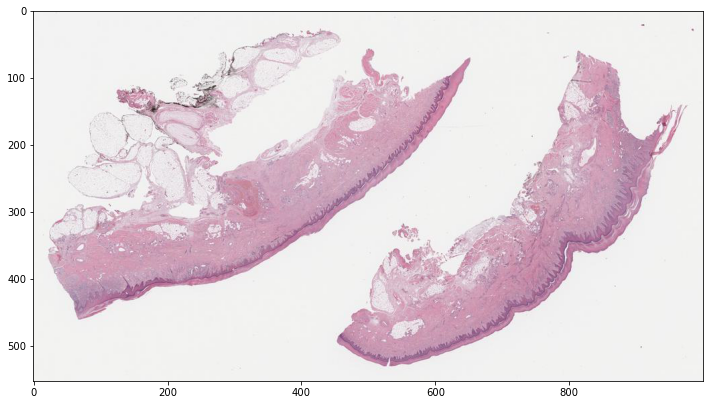

In [23]:
thumbs = results.joinpath('infer_outputs','thumbnails')
thumbs = [str(x) for x in thumbs.glob('*.jpg')]
print(thumbs[1])
img = mpimg.imread(thumbs[1])
fig = plt.figure(figsize=(12,12))
ax = fig.add_subplot(1,1,1)
ax.imshow(img)
plt.show()

# 8) Display heatmap generated of tumor condition:

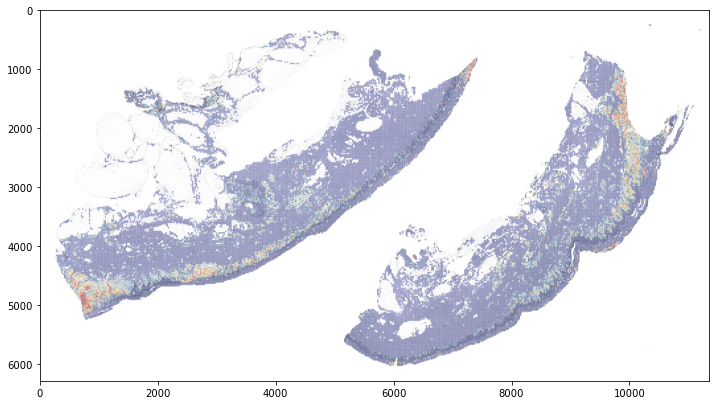

In [26]:
heatmaps = results.joinpath('infer_outputs','heatmap')
fns= [str(x) for x in heatmaps.glob('*pred_tumor_overlay_ds10x.jpg')]
img = mpimg.imread(fns[7])
fig = plt.figure(figsize=(12,12))
ax = fig.add_subplot(1,1,1)
ax.imshow(img)
plt.show()

# Notes


1. You can manually change sbatch command and copy paste in HPC terminal as well
* `#SBATCH --array=1-N` where N is the number of slides. this can be made into a list like `#SBATCH --array=1,3,5` to only re-run certain slides
* `PRJ="Your_Project_Folder_Name"`
* `BASE="/path/to/your/project/$PRJ"`
* Check that the sample list generated above and scripts of this repository are in the expected locations (`$BASE/sampleinfo` and `$BASE/scripts/pancan_pipe/` respectively)
2. Main options to select which parts of pipe to run:
* `RUN_THUMB=1` _Does not impact downstream, can be run without others, creates small thumbnail .jpg of WSI_
* `RUN_PREPROC=1` _only need to be performed once, creates tiles and filters artifacts_
* `KEEP_TILES=0` whether to copy tiles generated during preprocessing to results folder or discard. default is to discard (=0).
* `RUN_INFER=1` _Requires preproc, actually makes predictions about tumor / not tumor_
* `RUN_POST=1` _Requres preproc -> infer. Creates heatmaps, and geojson of tumor regions detected_
3. If you want to manually run pipeline, create a logs folder like /project/logs/round1, go there, and run the sbatch command
4. `cd /project_name/logs/round1`
5. `sbatch --array=1-N /path/to/pancan_pipe/pipeline/pancancer_pipe.sh` etc

* Note: log files will be created when the jobs exit slurm queue and begin
* Note: can be useful to grep the logs files to determine if any jobs ran out of time: grep "CANCEL" ./*.out
etc